**سوال 7**
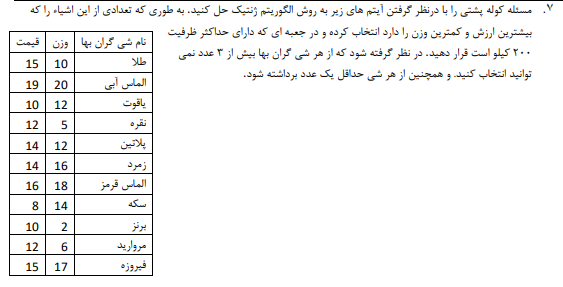

عمده الگوریتم این سوال نیز مانند سوال قبل است اما:

اینجا برخلاف سوال قبل میخواهیم برازش را **ماکسیمم** کنیم

برای انتخاب والدین از همان روش **رنکد** استفاده میکنیم

اما برای بازترکیب از **بازترکیب ترتیبی** در این سوال استفاده کردم و برای جهش نیز از روش **درهم سازی** استفاده کردم

البته چون در این سوال برخلاف سوال قبلی، بعد از ترکیب و جهش و همچنین در هنگام جنریت کردن کاندیداها امکان این وجود دارد که **محدودیت های صورت سوال نقض شود** لذا یک تابع نیز به منظور اطمینان از رعایت شدن محدودیت هانوشته شد تا بعد از ترکیب و جهش و جنریت کاندیدا ها خروجی آنها توسط این تابع به محدوده معین سوال برگردد


همچنین برای جایگزین کردن جمعیت اینجا نیز از همان روش **جایگزینی نسلی همراه با الیتیسم** استفاده کردم و نیز برای جلوگیری از رکود از مفهوم **ایمیگرنت** استفاده شد  

In [3]:
import random


weights = [10, 20, 12, 5, 12, 16, 18, 14, 2, 6, 17]
values  = [15, 19, 10, 12, 14, 14, 16, 8, 10, 12, 15]

MAX_W = 200


def fix(cand):

    total_w = sum(cand[i] * weights[i] for i in range(len(cand)))

    while total_w > MAX_W:

        i = random.randint(0, len(cand) - 1)

        if cand[i] > 1:
            cand[i] -= 1
            total_w -= weights[i]

    return cand


def fitness(cand):
    total_v = sum(cand[i] * values[i] for i in range(len(cand)))

    return total_v


def gen_cand():

    cand = [random.randint(1, 3) for _ in range(len(weights))]
    return fix(cand)


def choose(pop):

    sorted_pop = sorted(pop, key=fitness, reverse=True)

    n = len(sorted_pop)

    ranks = list(range(n, 0, -1))
    sum_ranks = sum(ranks)

    probs = [r / sum_ranks for r in ranks]

    return random.choices(sorted_pop, weights=probs, k=1)[0]


def cross(p1, p2):

    n = len(p1)

    a = random.randint(0, n - 2)
    b = random.randint(a + 1, n - 1)

    child = [None] * n

    #copy from p1
    for i in range(a, b + 1):
        child[i] = p1[i]

    #remaining from p2
    j = 0

    for i in range(n):

        if child[i] is None:
            child[i] = p2[j]
            j += 1

    return child


def mutate(cand, prob=0.3):

    if random.random() < prob:

        n = len(cand)

        a = random.randint(0, n - 2)
        b = random.randint(a + 1, n - 1)

        segment = cand[a:b + 1]

        random.shuffle(segment)

        cand[a:b + 1] = segment

    return cand


def genetic(pop_size=100, gens=300, elite_percent=10, patience=10, imig_percent=40):

    elite_size = int(pop_size * (elite_percent / 100))

    pop = [gen_cand() for _ in range(pop_size)]

    best_fitness = float("-inf")
    stagnation = 0

    for gen in range(gens):

        pop = sorted(pop, key=fitness, reverse=True)

        best_cand = pop[0]
        current_best = fitness(best_cand)

        if current_best > best_fitness:

            best_fitness = current_best
            stagnation = 0

        else:
            stagnation += 1

        next_pop = pop[:elite_size]

        while len(next_pop) < pop_size:

            p1 = choose(pop)
            p2 = choose(pop)

            child = cross(p1, p2)
            child = mutate(child)
            child = fix(child)

            next_pop.append(child)

        pop = next_pop

        #immigration
        if stagnation >= patience:

            imigs = int(pop_size * (imig_percent / 100))

            pop[-imigs:] = [gen_cand() for _ in range(imigs)]

            stagnation = 0

        if gen % 20 == 0:

            weight = sum(best_cand[i] * weights[i] for i in range(len(best_cand)))
            value = sum(best_cand[i] * values[i] for i in range(len(best_cand)))

            print("gen", gen," best =", best_cand, "value =", value, "weight =", weight, "fitness =", current_best)

    return best_cand


result = genetic()

weight = sum(result[i] * weights[i] for i in range(len(result)))
value = sum(result[i] * values[i] for i in range(len(result)))

print("\nfinal result =", result)
print("fitness =", round(fitness(result), 2))
print("total value =", value)
print("total weight =", weight)

gen 0  best = [3, 1, 1, 3, 2, 1, 2, 1, 3, 1, 1] value = 249 weight = 196 fitness = 249
gen 20  best = [3, 1, 1, 3, 3, 1, 1, 1, 2, 3, 1] value = 261 weight = 200 fitness = 261
gen 40  best = [3, 2, 1, 3, 1, 1, 1, 1, 3, 3, 1] value = 262 weight = 198 fitness = 262
gen 60  best = [3, 2, 1, 3, 1, 1, 1, 1, 3, 3, 1] value = 262 weight = 198 fitness = 262
gen 80  best = [3, 2, 1, 3, 1, 1, 1, 1, 3, 3, 1] value = 262 weight = 198 fitness = 262
gen 100  best = [3, 2, 1, 3, 1, 1, 1, 1, 3, 3, 1] value = 262 weight = 198 fitness = 262
gen 120  best = [3, 2, 1, 3, 1, 1, 1, 1, 3, 3, 1] value = 262 weight = 198 fitness = 262
gen 140  best = [3, 2, 1, 3, 1, 1, 1, 1, 3, 3, 1] value = 262 weight = 198 fitness = 262
gen 160  best = [3, 2, 1, 3, 1, 1, 1, 1, 3, 3, 1] value = 262 weight = 198 fitness = 262
gen 180  best = [3, 2, 1, 3, 1, 1, 1, 1, 3, 3, 1] value = 262 weight = 198 fitness = 262
gen 200  best = [3, 2, 1, 3, 1, 1, 1, 1, 3, 3, 1] value = 262 weight = 198 fitness = 262
gen 220  best = [3, 2, 1, 3